# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

They keep a linear combination of features but apply a nonlinear function (sigmoid) to produce valid probabilities between 0 and 1, unlike linear regression.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

It matches probabilistic outputs and penalizes confident wrong predictions more than MSE, making it ideal for classification.

3. True or false, and explain: Logistic regression is a linear model.

True (with nuance). Linear in the log-odds $b⋅x$, but nonlinear in predicted probability.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. It’s a standard classification model using probability thresholds.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. They represent change in log-odds, not probability.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. The model is linear in features; nonlinear relationships still require engineered features.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Logistic regression is better for classification problems, while ordinary least squares is better for continuous outcomes. Neither model is always better; it depends on the type of response variable.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`


1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

In [51]:

import pandas as pd

df = pd.read_csv("data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [52]:
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]
df = df[cols].copy()
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [53]:
print(df.isna().sum())
#df = df.dropna()

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


In [54]:
df["dropout"] = (df["Target"] == "Dropout").astype(int)

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

In [55]:
from sklearn.linear_model import LogisticRegression

X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = df["dropout"]

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X, y)

print("Intercept:", log_reg.intercept_[0])
print("Coefficients:")
for name, coef in zip(X.columns, log_reg.coef_[0]):
    print(f"{name}: {coef}")


Intercept: 0.4856926578796168
Coefficients:
Debtor: 0.5306254196925666
Tuition fees up to date: -2.55654243281313
Scholarship holder: -1.227441522252298
Age at enrollment: 0.04992541246433546


Debtor and Age at enrollment are associated with higher dropout probability, while Tuition fees up to date and Scholarship holder are associated with lower dropout probability, and yes, tuition being up to date appears to reduce dropout risk because its coefficient is strongly negative.

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

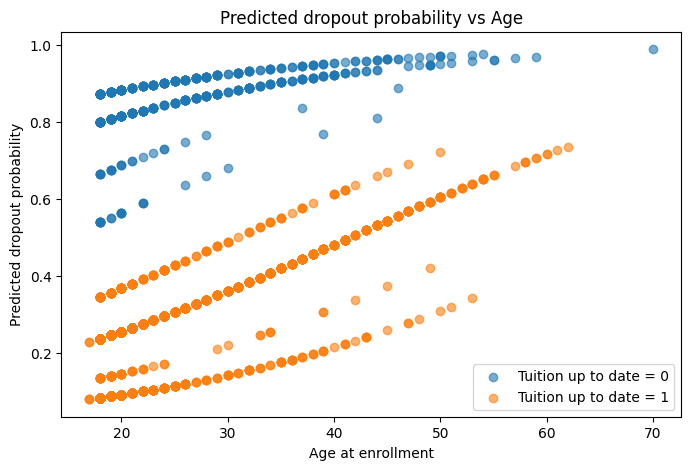


Average predicted dropout probability by tuition status:
Tuition fees up to date
0    0.860675
1    0.248090
Name: pred_prob_logistic, dtype: float64

Average change when tuition is up to date: -0.6125849339840048


In [56]:
import matplotlib.pyplot as plt

df["pred_prob_logistic"] = log_reg.predict_proba(X)[:, 1]

plt.figure(figsize=(8, 5))
for tuition_value in sorted(df["Tuition fees up to date"].unique()):
    subset = df[df["Tuition fees up to date"] == tuition_value]
    plt.scatter(
        subset["Age at enrollment"],
        subset["pred_prob_logistic"],
        label=f"Tuition up to date = {tuition_value}",
        alpha=0.6
    )

plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Predicted dropout probability vs Age")
plt.legend()
plt.show()

avg_by_tuition = df.groupby("Tuition fees up to date")["pred_prob_logistic"].mean()
print("\nAverage predicted dropout probability by tuition status:")
print(avg_by_tuition)

if 0 in avg_by_tuition.index and 1 in avg_by_tuition.index:
    print(
        "\nAverage change when tuition is up to date:",
        avg_by_tuition[1] - avg_by_tuition[0]
    )

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?



Confusion Matrix:
[[2841  162]
 [ 891  530]]

Accuracy: 0.7619801084990958


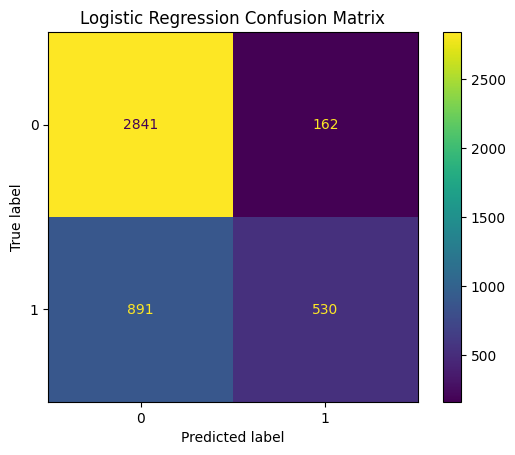

In [57]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

y_pred = log_reg.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("\nConfusion Matrix:")
print(cm)
print("\nAccuracy:", acc)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

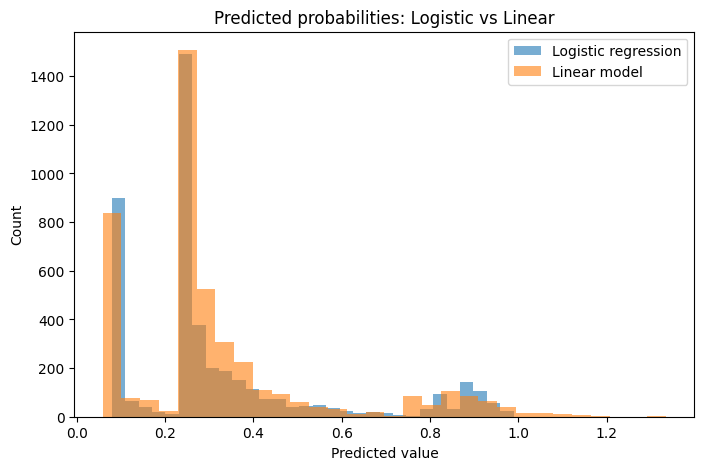


Linear model min/max predicted values:
0.05832035022573856 1.3349535706758708


In [58]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

df["pred_prob_linear"] = lin_reg.predict(X)

plt.figure(figsize=(8, 5))
plt.hist(df["pred_prob_logistic"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(df["pred_prob_linear"], bins=30, alpha=0.6, label="Linear model")
plt.xlabel("Predicted value")
plt.ylabel("Count")
plt.title("Predicted probabilities: Logistic vs Linear")
plt.legend()
plt.show()

print("\nLinear model min/max predicted values:")
print(df["pred_prob_linear"].min(), df["pred_prob_linear"].max())


6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

The students most at risk of dropping out are those who are debtors, not up to date on tuition, not scholarship holders, and older at enrollment. Interventions could include financial aid support, tuition payment plans, proactive advising, and early academic support.

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Multinomial classes:
['Dropout' 'Enrolled' 'Graduate']

Multinomial confusion matrix:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


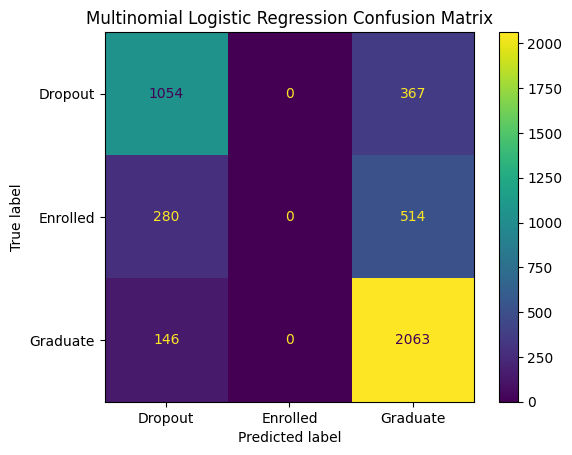


First 5 predicted class probabilities:
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104


In [59]:
X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = df["Target"]

multi_log_reg = LogisticRegression(max_iter=1000, multi_class="multinomial")
multi_log_reg.fit(X_multi, y_multi)

y_multi_pred = multi_log_reg.predict(X_multi)
cm_multi = confusion_matrix(y_multi, y_multi_pred, labels=multi_log_reg.classes_)

print("\nMultinomial classes:")
print(multi_log_reg.classes_)

print("\nMultinomial confusion matrix:")
print(cm_multi)

ConfusionMatrixDisplay(
    confusion_matrix=cm_multi,
    display_labels=multi_log_reg.classes_
).plot()
plt.title("Multinomial Logistic Regression Confusion Matrix")
plt.show()

multi_probs = multi_log_reg.predict_proba(X_multi)
multi_prob_df = pd.DataFrame(multi_probs, columns=multi_log_reg.classes_)

print("\nFirst 5 predicted class probabilities:")
print(multi_prob_df.head())

In [71]:
# The confusion matrix shows the hard classification predicts no one as Enrolled because the middle
# prediction column is all zeros, even though the probability output still gives nonzero probability
# to Enrolled

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

In [60]:
import pandas as pd

df = pd.read_csv('cirrhosis.csv')
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [61]:
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols].copy()
df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [62]:
df.shape

(418, 5)

In [63]:
print(df.isna().sum())
df = df.dropna()
# dropped rows with missing values for simplicity because the dataset only had missingness in Drug

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


In [64]:
df["alive"] = df["Status"].isin(["C", "CL"]).astype(int)
df_encoded = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)


2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

In [65]:
from sklearn.linear_model import LogisticRegression

X = df_encoded.drop(columns=["Stage", "Status", "alive"])
y = df_encoded["alive"]

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X, y)

print("Intercept:", log_reg.intercept_[0])
print("Coefficients:")
for name, coef in zip(X.columns, log_reg.coef_[0]):
    print(f"{name}: {coef}")

Intercept: 1.3798277993022918
Coefficients:
Bilirubin: -0.35142389843544086
Edema_S: -0.45067663255235757
Edema_Y: -1.6110491833168035
Drug_Placebo: 0.23122512449170882


3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

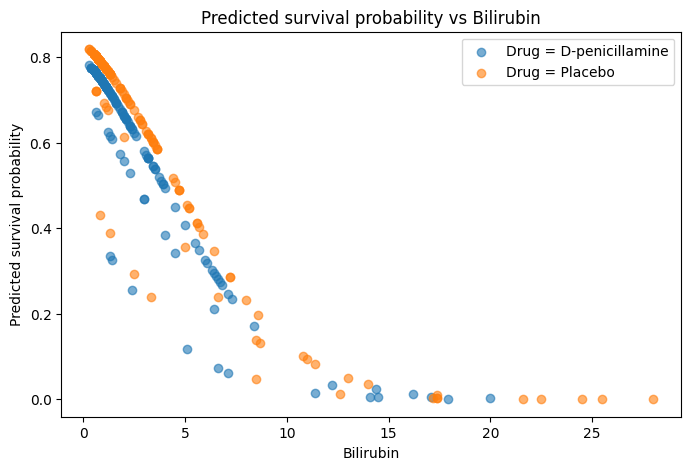


Average predicted survival probability by drug:
Drug_original
D-penicillamine    0.590054
Placebo            0.608902
Name: pred_prob_logistic, dtype: float64

Average change when taking D-penicillamine: -0.01884850103850899


In [66]:
import matplotlib.pyplot as plt

df_encoded["pred_prob_logistic"] = log_reg.predict_proba(X)[:, 1]

df_encoded["Drug_original"] = df["Drug"].values
df_encoded["Bilirubin_original"] = df["Bilirubin"].values

plt.figure(figsize=(8, 5))
for drug_value in df_encoded["Drug_original"].unique():
    subset = df_encoded[df_encoded["Drug_original"] == drug_value]
    plt.scatter(
        subset["Bilirubin_original"],
        subset["pred_prob_logistic"],
        label=f"Drug = {drug_value}",
        alpha=0.6
    )

plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival probability vs Bilirubin")
plt.legend()
plt.show()

avg_by_drug = df_encoded.groupby("Drug_original")["pred_prob_logistic"].mean()
print("\nAverage predicted survival probability by drug:")
print(avg_by_drug)

if "D-penicillamine" in avg_by_drug.index and "Placebo" in avg_by_drug.index:
    print(
        "\nAverage change when taking D-penicillamine:",
        avg_by_drug["D-penicillamine"] - avg_by_drug["Placebo"]
    )


The drug does not appear to increase survival probability on average. Patients taking D-penicillamine have a predicted survival probability about 0.019 lower than patients taking placebo, though the effect looks fairly small.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?


Confusion Matrix:
[[ 59  66]
 [ 16 171]]

Accuracy: 0.7371794871794872


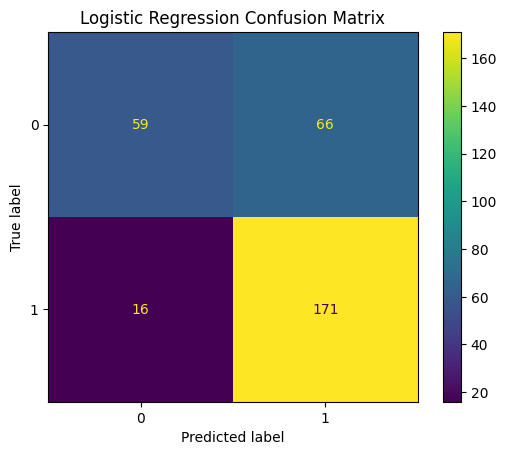

In [67]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

y_pred = log_reg.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("\nConfusion Matrix:")
print(cm)
print("\nAccuracy:", acc)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

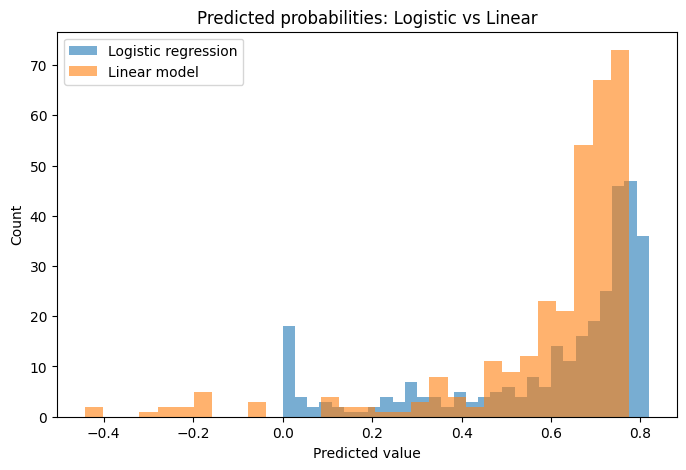


Linear model min/max predicted values:
-0.4417396683935991 0.7738680250928711


In [68]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

df_encoded["pred_prob_linear"] = lin_reg.predict(X)

plt.figure(figsize=(8, 5))
plt.hist(df_encoded["pred_prob_logistic"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(df_encoded["pred_prob_linear"], bins=30, alpha=0.6, label="Linear model")
plt.xlabel("Predicted value")
plt.ylabel("Count")
plt.title("Predicted probabilities: Logistic vs Linear")
plt.legend()
plt.show()

print("\nLinear model min/max predicted values:")
print(df_encoded["pred_prob_linear"].min(), df_encoded["pred_prob_linear"].max())

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Stage classes:
[1. 2. 3. 4.]

Stage confusion matrix:
[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]


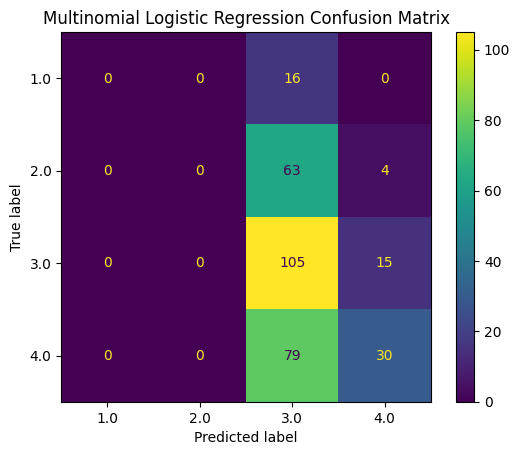

In [69]:
X_stage = df_encoded[[
    "Bilirubin",
    "Edema_S",
    "Edema_Y"
]]
y_stage = df["Stage"]

stage_log_reg = LogisticRegression(max_iter=1000)
stage_log_reg.fit(X_stage, y_stage)

y_stage_pred = stage_log_reg.predict(X_stage)
cm_stage = confusion_matrix(y_stage, y_stage_pred, labels=stage_log_reg.classes_)

print("\nStage classes:")
print(stage_log_reg.classes_)

print("\nStage confusion matrix:")
print(cm_stage)

ConfusionMatrixDisplay(
    confusion_matrix=cm_stage,
    display_labels=stage_log_reg.classes_
).plot()
plt.title("Multinomial Logistic Regression Confusion Matrix")
plt.show()

stage_probs = stage_log_reg.predict_proba(X_stage)
stage_prob_df = pd.DataFrame(stage_probs, columns=stage_log_reg.classes_)

In [72]:
# The hard classification only predicts stages 3 and 4, not 1 or 2

In [70]:
X_stage.dtypes

,0
Bilirubin,float64
Edema_S,bool
Edema_Y,bool


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

$
\hat{y} = b_0 + \sum_{k=1}^K b_k x_k
\
$

$\
\frac{\partial \hat{y}}{\partial x_k} = b_k
$


A one-unit increase in ($x_k$), holding all other variables constant, changes the prediction by exactly ($b_k$).  
The effect is constant and does not depend on ($x$).

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?


$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}
$

$
\frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1 - \hat{p}) \, b_k
$

The effect is not constant and depends on the current predicted probability $\hat{p}$. It is largest when $\hat{p}$ $\approx$ 0.5, since $\hat{p}(1-\hat{p})$ is maximized at about 0.25. In this case, the change is approximately $\frac{b_k}{4}$.  

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

$
\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x
$

A one-unit increase in ($x_k$) increases the **log-odds** by ($b_k$), holding other variables fixed.  
Equivalently, it multiplies the odds by ($e^{b_k}$).